In [19]:
from google import genai
from dotenv import load_dotenv
import os
load_dotenv()
client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

In [20]:
from langgraph.graph import StateGraph , START, END
from typing import TypedDict , Optional

In [32]:
from pydantic import BaseModel
class ClarityEvaluation(BaseModel):
    clarity_score: int
    feedback: str

class DepthEvaluation(BaseModel):
    depth_score: int
    feedback: str

class GrammarEvaluation(BaseModel):
    grammar_score: int
    feedback: str

In [22]:
class EssaySchema(TypedDict):
    essay_text: str
    clarity_score: Optional[int]
    clarity_feedback: Optional[str]

    depth_score: Optional[int]
    depth_feedback: Optional[str]
    
    grammar_score: Optional[int]
    grammar_feedback: Optional[str]

In [23]:
def essay_clarity(state: EssaySchema) -> dict:
    essay = state['essay_text']
    prompt = f"Evaluate the essay on the basis of clarity and assign a score of 0-10. \n\n {essay}"

    response = client.models.generate_content(
            model="gemma-4-26b-a4b-it",
            contents=prompt,
            config={
                "response_mime_type": "application/json",
                "response_schema": ClarityEvaluation,
            },
        )
    result = response.parsed
    return {
        "clarity_score":result.clarity_score,
        "clarity_feedback":result.feedback,
    }

In [24]:
def essay_depth(state: EssaySchema) -> dict:
    essay = state['essay_text']
    prompt = f"Evaluate the essay on the basis of depth and assign a score of 0-10. \n\n {essay}"

    response = client.models.generate_content(
            model="gemma-4-26b-a4b-it",
            contents=prompt,
            config={
                "response_mime_type": "application/json",
                "response_schema": DepthEvaluation,
            },
        )
    result = response.parsed
    return {
        "depth_score":result.depth_score,
        "depth_feedback":result.feedback,
    }

In [25]:
def essay_grammar(state: EssaySchema) -> dict:
    essay = state['essay_text']
    prompt = f"Evaluate the essay on the basis of grammar and assign a score of 0-10. \n\n {essay}"

    response = client.models.generate_content(
            model="gemma-4-26b-a4b-it",
            contents=prompt,
            config={
                "response_mime_type": "application/json",
                "response_schema": GrammarEvaluation,
            },
        )
    result = response.parsed
    return {
        "grammar_score":result.grammar_score,
        "grammar_feedback":result.feedback,
    }

In [26]:
graph = StateGraph(EssaySchema)

graph.add_node("essay_clarity",essay_clarity)
graph.add_node("essay_depth",essay_depth)
graph.add_node("essay_grammar",essay_grammar)

graph.add_edge(START,"essay_clarity")
graph.add_edge(START,"essay_depth")
graph.add_edge(START,"essay_grammar")

graph.add_edge("essay_clarity",END)
graph.add_edge("essay_clarity",END)
graph.add_edge("essay_clarity",END)

In [29]:
app = graph.compile()

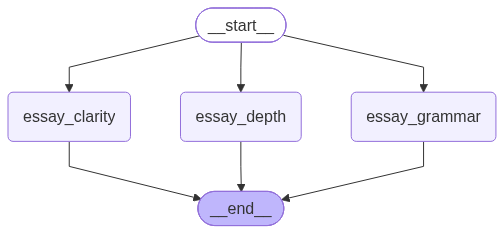

In [30]:
app

In [28]:
essay = "Climate change are one of the biggest issue facing our planet today. Rising temperatures has caused glaciers to melt at an alarming rate, which contribute to rising sea levels and threatens coastal cities. Many scientists believes that unless carbon emissions are reduced significantly in the next decade, some of these effects could become irreversible. Governments and individuals both plays a role in addressing this crisis, through policy changes and everyday choices like reducing energy consumption."

In [33]:
result = app.invoke({"essay_text":essay})

In [34]:
result

{'essay_text': 'Climate change are one of the biggest issue facing our planet today. Rising temperatures has caused glaciers to melt at an alarming rate, which contribute to rising sea levels and threatens coastal cities. Many scientists believes that unless carbon emissions are reduced significantly in the next decade, some of these effects could become irreversible. Governments and individuals both plays a role in addressing this crisis, through policy changes and everyday choices like reducing energy consumption.',
 'clarity_score': 7,
 'clarity_feedback': 'The essay is clear in its message and structure, but it suffers from several subject-verb agreement errors (e.g., ""Climate change are"", ""Rising temperatures has"", ""scientists believes"", ""individuals both plays"") that detract from the grammatical correctness and overall professional tone.',
 'depth_score': 4,
 'depth_feedback': "The essay touches upon key aspects of climate change, such as melting glaciers, sea levels, and

In [35]:
import textwrap

for key, value in result.items():
    print(f"{key}:")
    if isinstance(value, str) and len(value) > 80:
        print(textwrap.fill(value, width=80))
    else:
        print(value)
    print()

essay_text:
Climate change are one of the biggest issue facing our planet today. Rising
temperatures has caused glaciers to melt at an alarming rate, which contribute
to rising sea levels and threatens coastal cities. Many scientists believes that
unless carbon emissions are reduced significantly in the next decade, some of
these effects could become irreversible. Governments and individuals both plays
a role in addressing this crisis, through policy changes and everyday choices
like reducing energy consumption.

clarity_score:
7

clarity_feedback:
The essay is clear in its message and structure, but it suffers from several
subject-verb agreement errors (e.g., ""Climate change are"", ""Rising
temperatures has"", ""scientists believes"", ""individuals both plays"") that
detract from the grammatical correctness and overall professional tone.

depth_score:
4

depth_feedback:
The essay touches upon key aspects of climate change, such as melting glaciers,
sea levels, and the importance of r